# **Average-Pooling Downsampling and STMGraph Upsampling**

In [1]:
import scanpy as sc
import anndata
import pandas as pd
# import STMGraph_pyG0 as STMGraph
# import SMGraph_pyG as STMGraph
# import SM2ST as SMLED
# import SMLED
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import pearsonr
os.environ['R_HOME'] = '/home/llx/software/miniconda3/envs/pyg_ms/lib/R'

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  **1 Read MSI**

In [ ]:
# df_ms=pd.read_csv('/home/llx/project/jupyternotebook/1_pyg_backup/Data/MSD/mouse_brain_pen_dhb_50um_pixel_intensities.csv', skiprows=2,index_col=0)
df_ms=pd.read_csv('/home/llx/project/MSI_data/2025_2_21_mouse_brain/15um/bruker_ITO_glass_15um_c.csv',index_col=0)
df_ms

In [ ]:
column_sums_i1 = df_ms.sum(axis = 1)/len(df_ms.columns)
column_sums_i1.index = column_sums_i1.index.astype(float)
# 绘制折线图
column_sums_i1.plot(kind='line', marker='.',linewidth=0.6, markersize=1)
plt.title('Sum of Each Column')
plt.xlabel('Index')
plt.ylabel('Sum')
plt.xticks(range(0, 1500, 100))  # 设置横轴刻度，每100个单位显示一个刻度
plt.xlim(column_sums_i1.index.min(), column_sums_i1.index.max())  # 设置横轴范围
# plt.xlim(850, 860)
plt.grid(True)
plt.show()

##  **2 create anndata**

In [5]:
# Divide the data into four groups (odd column, odd row), (even column, even row), (odd column, even row), (even column, odd row), 
# Then sum them all up and divide by 4. Use the coordinate of (odd column, odd row) as the coordinate, 
# then take the remainder after dividing by 2, which is the new coordinate. 
# This way, the downsampling and averaging pooling can be completed.

In [6]:
import re

def split_by_xy_parity(dataframe):
    """按x和y坐标的奇偶性分割表格"""
    pattern = re.compile(r'x(\d+)_y(\d+)')
    
    groups = {
        'odd_x_odd_y': [],
        'odd_x_even_y': [],
        'even_x_odd_y': [],
        'even_x_even_y': []
    }
    
    for col in dataframe.columns:
        match = pattern.match(col)
        if match:
            x = int(match.group(1))
            y = int(match.group(2))
            
            if x % 2 == 1 and y % 2 == 1:
                groups['odd_x_odd_y'].append(col)
            elif x % 2 == 1 and y % 2 == 0:
                groups['odd_x_even_y'].append(col)
            elif x % 2 == 0 and y % 2 == 1:
                groups['even_x_odd_y'].append(col)
            else:
                groups['even_x_even_y'].append(col)
    
    return {name: dataframe[cols] for name, cols in groups.items()}


def create_anndata(dataframe=None,pixel_size=1):
    
    df_ms_new=dataframe.iloc[:,:].T
    # 检查每一行是否所有元素都是0
    # 收集所有坐标到列表中
    rows = []
    cols = []
    index_names =[]
    df_ms_new_sorted = df_ms_new.sort_index()

    # coordinates_df 和 coordinates_physical_df 也按相同的顺序排序
    df_ms_new = df_ms_new.loc[df_ms_new_sorted.index]
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:])//2)
        cols.append(int(y)//2)
        index_names.append('x'+str(int(x[1:])//2)+'_'+'y'+str(int(y)//2))

    # 使用列表一次性创建DataFrame
    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = index_names
    
    coordinates_physical_df = coordinates_df*pixel_size
    # 初始化 AnnData 对象
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [7]:
import pandas as pd
from anndata import AnnData
from scipy.sparse import issparse
# Average pooling
def downsample_anndata(a0: AnnData, a1: AnnData) -> AnnData:
    """
    合并两个AnnData对象：
    - obs_names相同的交集：X矩阵相加除以2（取平均）
    - 交集以外的数据：保留原始值
    
    参数:
        a0, a1: 两个AnnData对象，要求var_names相同
        
    返回:
        合并后的AnnData对象
    """
    # 1. 检查var_names是否一致（必须保证特征维度相同）
    if not a0.var_names.equals(a1.var_names):
        raise ValueError("两个AnnData对象的var_names必须完全相同")
    
    # 2. 找出交集和各自独有的obs_names
    common_obs = a0.obs_names.intersection(a1.obs_names)  # 交集
    a0_unique = a0.obs_names.difference(a1.obs_names)    # 仅a0有的
    a1_unique = a1.obs_names.difference(a0.obs_names)    # 仅a1有的
    
    # 3. 准备合并的数据片段
    adata_parts = []
    
    # 处理交集部分：取平均值
    if len(common_obs) > 0:
        # 提取交集数据（copy避免修改原数据）
        a0_common = a0[common_obs].copy()
        a1_common = a1[common_obs].copy()
        
        # 计算平均值（支持稀疏矩阵）
        a0_common.X = (a0_common.X + a1_common.X) / 2
        
        adata_parts.append(a0_common)
    
    # 添加a0独有的部分
    if len(a0_unique) > 0:
        adata_parts.append(a0[a0_unique].copy())
    
    # 添加a1独有的部分
    if len(a1_unique) > 0:
        adata_parts.append(a1[a1_unique].copy())
    
    # 4. 合并所有部分
    if not adata_parts:  # 都为空
        return AnnData(var=a0.var.copy())
    elif len(adata_parts) == 1:  # 只有一个部分
        return adata_parts[0]
    else:
        # 使用anndata的concatenate方法合并
        # join='outer'确保保留所有特征
        # batch_key=None不添加批次信息
        # index_unique=None保持原始obs_names不变
        result = adata_parts[0].concatenate(
            adata_parts[1:],
            join='outer',
            batch_key=None,
            index_unique=None
        )
        return result

In [8]:
results = split_by_xy_parity(df_ms)
df0 = results['odd_x_odd_y']
df1 = results['odd_x_even_y']
df2 = results['odd_x_even_y']
df3 = results['even_x_even_y']

adata0 = create_anndata(dataframe=df0,pixel_size=30)
adata1 = create_anndata(dataframe=df1,pixel_size=30)
adata2 = create_anndata(dataframe=df2,pixel_size=30)
adata3 = create_anndata(dataframe=df3,pixel_size=30)

adata01 = downsample_anndata(adata0, adata1)
adata012 = downsample_anndata(adata01, adata2)
adata0123 = downsample_anndata(adata012, adata3)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_391283/1154268571.py:58: FutureWarning: Use anndata.c

In [9]:
sc.pp.normalize_total(adata0123, target_sum=1e4)
sc.pp.log1p(adata0123)

In [10]:
def create_anndata_or(dataframe=None,pixel_size=1,mask_radio=0.5):
    
    df_ms_new=dataframe.iloc[:,:].T#4
    # 检查每一行是否所有元素都是0
    rows_all_zero = (df_ms_new == 0).all(axis=1)
    
    # 使用布尔索引删除所有元素都是0的行
    df_ms_new = df_ms_new[~rows_all_zero]
    df_ms_new = df_ms_new.apply(lambda x: x - x.min(), axis=0)
    # 收集所有坐标到列表中
    rows = []
    cols = []
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:]))
        cols.append(int(y))

    # 使用列表一次性创建DataFrame
    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = df_ms_new.index
    coordinates_physical_df = coordinates_df*pixel_size
    # 初始化 AnnData 对象
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [11]:
adata = create_anndata_or(dataframe=df_ms,pixel_size=15)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
adata.obsm['spatial']

array([[5610,   15],
       [5625,   15],
       [5640,   15],
       ...,
       [3225, 5280],
       [3240, 5280],
       [3255, 5280]])

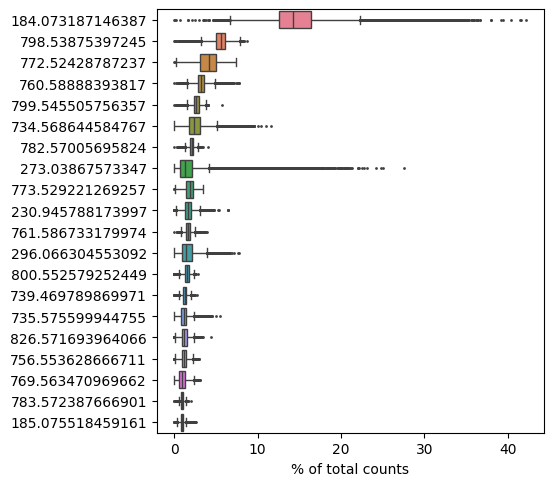

In [13]:
sc.pl.highest_expr_genes(adata, n_top=20, )

<Axes: title={'center': '152.055701908573'}, xlabel='spatial1', ylabel='spatial2'>

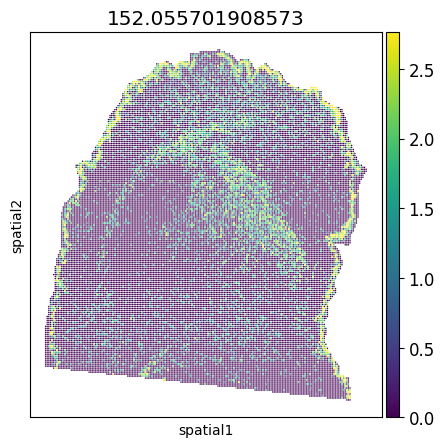

In [14]:
plot_gene = '152.055701908573'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(adata0123, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '850.562673745131'}, xlabel='spatial1', ylabel='spatial2'>

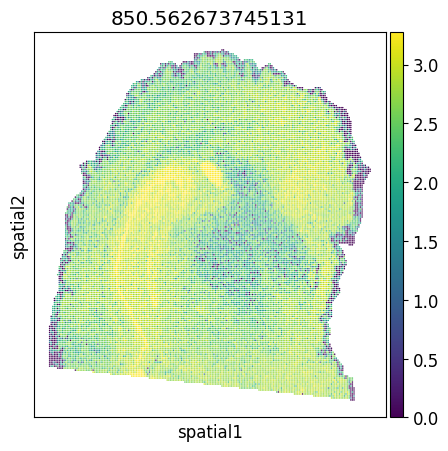

In [15]:
#new
plot_gene = '850.562673745131'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata0123, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.055701908573'}, xlabel='spatial1', ylabel='spatial2'>

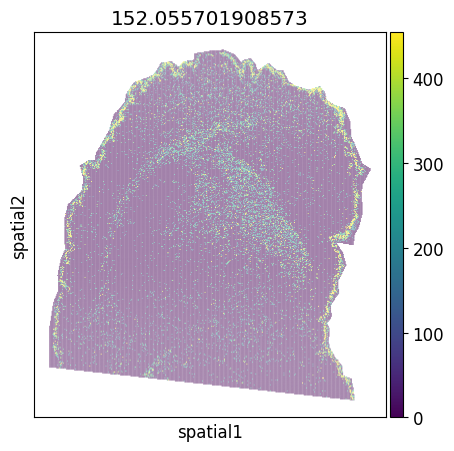

In [16]:
plot_gene = '152.055701908573'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '850.562673745131'}, xlabel='spatial1', ylabel='spatial2'>

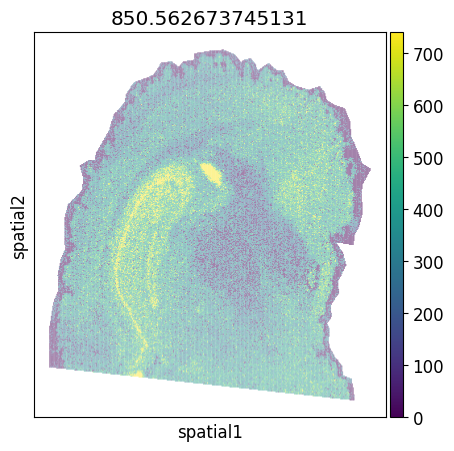

In [17]:
#new
plot_gene = '850.562673745131'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [18]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

<Axes: title={'center': '850.562673745131'}, xlabel='spatial1', ylabel='spatial2'>

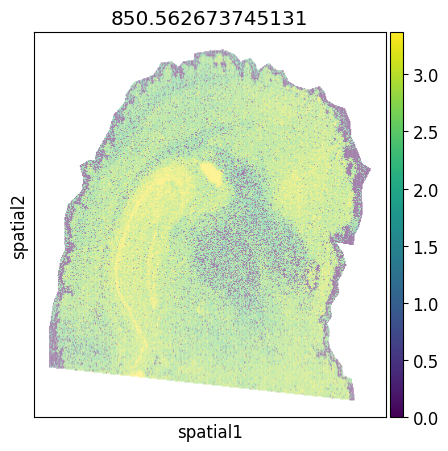

In [19]:
#new
plot_gene = '850.562673745131'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '870.540990798999'}, xlabel='spatial1', ylabel='spatial2'>

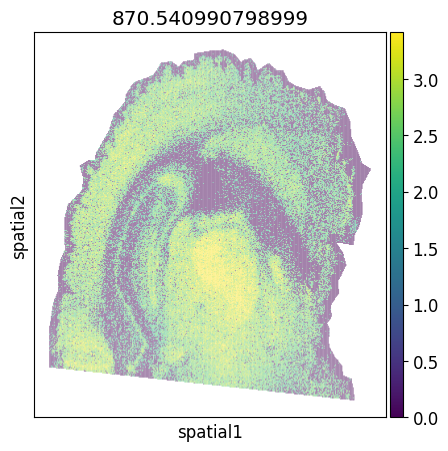

In [20]:
#870.540990798999, 871.545065979268, 872.556620337435, 873.560064728065, 874.500122495562, 874.564099012713, 875.503255460795, 875.567625938191, 876.505263332617, 876.585297078691, 877.590033013271, 896.48225453801
plot_gene = '870.540990798999'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '851.565253947911'}, xlabel='spatial1', ylabel='spatial2'>

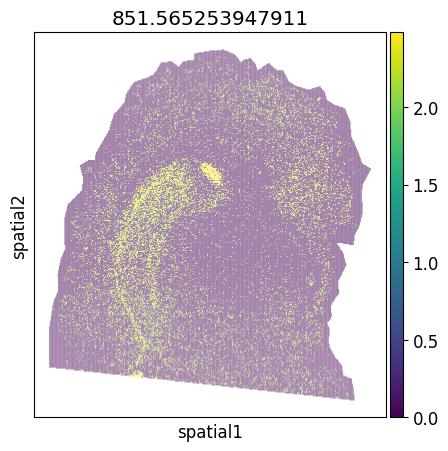

In [44]:
#new
plot_gene = '851.565253947911'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [21]:
import STMGraph_pyG1

In [23]:
adata

AnnData object with n_obs × n_vars = 105440 × 954
    obs: 'array_row', 'array_col'
    uns: 'log1p'
    obsm: 'spatial'

## **3 super resolution**

### **3.1 Interpolation**

In [24]:
def anndata_transfer_resolution2(adata=None,pixel_size=1):
    original_coordinates = adata.obsm['spatial'].copy()
    new_coordinates_1 = adata.obsm['spatial'].copy()
    new_coordinates_1[:,1] =  new_coordinates_1[:,1] + pixel_size//2
    new_adata_1=adata.copy()
    # 将矩阵除以25
    divided_new_coordinates_1 = new_coordinates_1 // (pixel_size//2)
    # 创建一个DataFrame，列名设置为 'array_row' 和 'array_col'
    df_divided_new_coordinates_1 = pd.DataFrame(divided_new_coordinates_1, columns=['array_row', 'array_col'])
    new_adata_1.obs = df_divided_new_coordinates_1
    new_adata_1.obsm['spatial'] = new_coordinates_1
    adata_combined_1 = sc.concat([adata, new_adata_1], axis=0, join='outer', uns_merge='unique')
    
    new_coordinates_2 = adata_combined_1.obsm['spatial'].copy()
    new_coordinates_2 = new_coordinates_2.copy()
    new_coordinates_2[:,0] =  new_coordinates_2[:,0] + pixel_size//2
    new_adata_2=adata_combined_1.copy()
    # 将矩阵除以25
    divided_new_coordinates_2 = new_coordinates_2 // (pixel_size//2)
    # 创建一个DataFrame，列名设置为 'array_row' 和 'array_col'
    df_divided_new_coordinates_2 = pd.DataFrame(divided_new_coordinates_2, columns=['array_row', 'array_col'])
    new_adata_2.obs = df_divided_new_coordinates_2
    new_adata_2.obsm['spatial'] = new_coordinates_2
    adata_combined_2 = sc.concat([adata_combined_1, new_adata_2], axis=0, join='outer', uns_merge='unique')
    # 重置 .obs DataFrame 的索引，从0开始
    adata_combined_2.obs = adata_combined_2.obs.reset_index(drop=True)
    adata_combined_2.obs_names = adata_combined_2.obs_names.astype(str)
    grid_coords = adata_combined_2.obsm['spatial'] // (pixel_size // 2)
    # 生成格式为"xn_ym"的obs_names
    adata_combined_2.obs_names = ['x{}_y{}'.format(int(x), int(y)) for x, y in grid_coords]
    return adata_combined_2

In [25]:
new_adata = anndata_transfer_resolution2(adata=adata0123,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [26]:
new_adata_copy = new_adata.copy()

In [46]:
new_adata = new_adata_copy

In [53]:
# new_adata.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15-30um_c_new.h5ad')

In [38]:
# new_adata_o = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15um_c_new.h5ad')

In [49]:
# 处理边缘,过滤非common spot
import numpy as np
import scanpy as sc

# 找到共同的细胞名称(因为名称已经命名为对应spot坐标了)
common_cells = new_adata.obs_names.intersection(adata.obs_names)

# 创建adata_o的副本（避免直接修改原数据）
adata_o_modified = adata.copy()
adata_o_modified.X = np.zeros_like(adata_o_modified.X)

# 或者更简洁的向量化操作（推荐）
common_idx_o = [adata.obs_names.get_loc(c) for c in common_cells]
common_idx = [new_adata.obs_names.get_loc(c) for c in common_cells]

adata_o_modified.X[common_idx_o, :] = new_adata.X[common_idx, :]

In [50]:
new_adata = adata_o_modified

In [51]:
new_adata

AnnData object with n_obs × n_vars = 105440 × 954
    obs: 'array_row', 'array_col'
    uns: 'log1p'
    obsm: 'spatial'

<Axes: title={'center': '851.565253947911'}, xlabel='spatial1', ylabel='spatial2'>

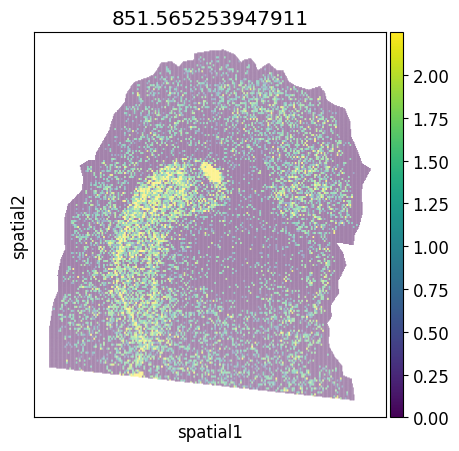

In [52]:
#new
plot_gene = '851.565253947911'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(new_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '837.670012242575'}, xlabel='spatial1', ylabel='spatial2'>

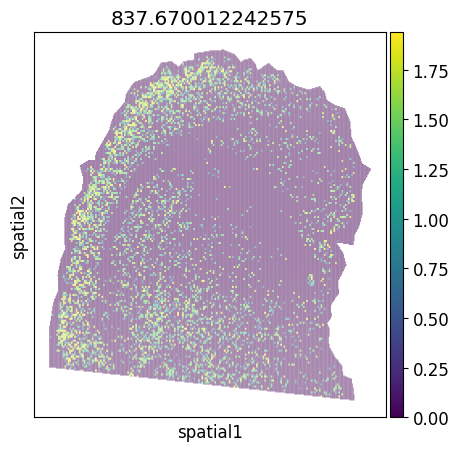

In [54]:
#new
plot_gene = '837.670012242575'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(new_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '837.670012242575'}, xlabel='spatial1', ylabel='spatial2'>

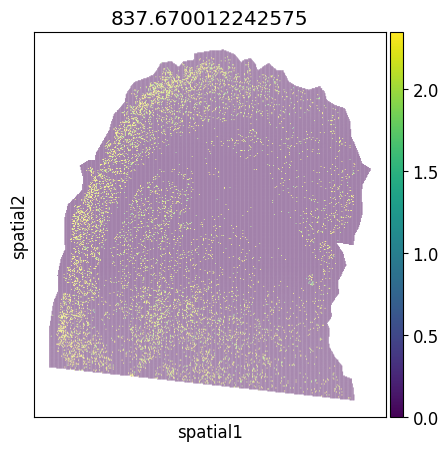

In [32]:
#new
plot_gene = '837.670012242575'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '896.48225453801'}, xlabel='spatial1', ylabel='spatial2'>

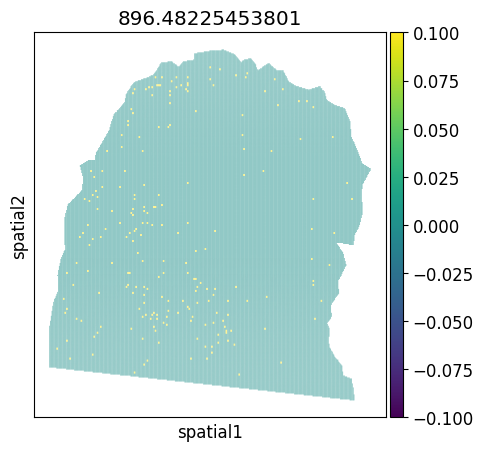

In [33]:
#new
plot_gene = '896.48225453801'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(new_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

### **3.2 STMGraph Correction**

In [34]:
import random
import torch.backends.cudnn as cudnn
import torch
# torch.set_default_dtype(torch.float64)
def fix_seed(seed):
    #seed = 2023
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    cudnn.deterministic = True
    cudnn.benchmark = False
    # torch.use_deterministic_algorithms(True)  # 强制报错非确定性操作
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  
seed = 52
fix_seed(seed)

In [35]:
# grid setting
num_batch_x = 3
num_batch_y = 2
new_adata.obs['x'] = new_adata.obsm['spatial'][:,0]
new_adata.obs['y'] = new_adata.obsm['spatial'][:,1]

In [36]:
import seaborn as sns
def Batch_Data(adata, num_batch_x, num_batch_y, spatial_key=['X', 'Y'], plot_Stats=False):
    Sp_df = adata.obs.loc[:, spatial_key].copy()
    Sp_df = np.array(Sp_df)
    batch_x_coor_1 = [np.percentile(Sp_df[:, 0], (1/num_batch_x)*x*100) for x in range(num_batch_x+1)]
    batch_y_coor_1 = [np.percentile(Sp_df[:, 1], (1/num_batch_y)*x*100) for x in range(num_batch_y+1)]
    batch_x_coor_2 = [np.percentile(Sp_df[:, 0], (1/(num_batch_x*2))*x*100) for x in range(1,num_batch_x*2+1,2)]
    batch_y_coor_2 = [np.percentile(Sp_df[:, 1], (1/(num_batch_y*2))*x*100) for x in range(1,num_batch_y*2+1,2)]
    
    Batch_list = []
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y-1):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y-1):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    if plot_Stats:
        f, ax = plt.subplots(figsize=(1, 3))
        plot_df = pd.DataFrame([x.shape[0] for x in Batch_list], columns=['#spot/batch'])
        sns.boxplot(y='#spot/batch', data=plot_df, ax=ax)
        sns.stripplot(y='#spot/batch', data=plot_df, ax=ax, color='red', size=5)
    return Batch_list

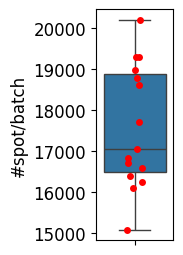

In [37]:
Batch_list_1 = Batch_Data(new_adata, num_batch_x=num_batch_x, num_batch_y=num_batch_y,spatial_key=['x', 'y'], plot_Stats=True)

In [38]:
# Consturcting network for each batch
for temp_adata in Batch_list_1:
    STMGraph_pyG1.Cal_Spatial_Net(temp_adata, model='KNN', k_cutoff=8, delta_err=0.05)
    #STAGATE_pyG.Stats_Spatial_Net(temp_adata)

------Calculating spatial graph...
The graph contains 159884 edges, 20201 cells.
7.9147 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


------Calculating spatial graph...
The graph contains 119014 edges, 15085 cells.
7.8896 neighbors per cell on average.
------Calculating spatial graph...


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 129478 edges, 16380 cells.
7.9046 neighbors per cell on average.
------Calculating spatial graph...


...

/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


The graph contains 127198 edges, 16092 cells.
7.9044 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


------Calculating spatial graph...
The graph contains 140044 edges, 17719 cells.
7.9036 neighbors per cell on average.


/home/llx/project/jupyternotebook/1_pyg_backup/STMGraph_pyG1/utils.py:112: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['Spatial_Net'] = Spatial_Net


In [39]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
data_list1 = [STMGraph_pyG1.Transfer_pytorch_Data(temp_adata) for temp_adata in Batch_list_1]
for temp in data_list1:
    temp.to(device)

In [40]:
STMGraph_pyG1.Cal_Spatial_Net(new_adata, model='KNN', k_cutoff=8, delta_err=0.05)
adata_om1 = STMGraph_pyG1.Transfer_pytorch_Data(new_adata)

------Calculating spatial graph...
The graph contains 839278 edges, 105440 cells.
7.9598 neighbors per cell on average.


In [41]:
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

num_epoch = 600
delayed_ema_epoch = 130 # 110
lr=0.0001
weight_decay=1e-4
hidden_dims = [512, 30]
alpha = 1
mask_ratio = 0.5
noise = 0.0
# gradient_clipping = 5.

def sce_loss(x, y, alpha=1.0):
    x = F.normalize(x, p=2, dim=-1)
    y = F.normalize(y, p=2, dim=-1)
    loss = (1 - (x * y).sum(dim=-1)).pow_(alpha)
    loss = loss.mean()
    return loss
# batch_size=1 or 2
loader = DataLoader(data_list1, batch_size=1, shuffle=True,num_workers = 0)
model = STMGraph_pyG1.STMGraph(hidden_dims = [data_list1[0].x.shape[1]]+hidden_dims,delayed_ema_epoch=delayed_ema_epoch, momentum=0.996).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

total_steps = num_epoch * len(loader)
pbar = tqdm(total=total_steps, desc='Training')

for epoch in range(1, num_epoch + 1):
    for batch in loader:
        model.train()
        optimizer.zero_grad()

        z, z_ema, out1, out2, mask_nodes, keep_nodes, ATT = model(
            epoch, batch.x, batch.edge_index,
            mask_rate=mask_ratio, replace_rate=noise
        )

        loss1 = sce_loss(batch.x[mask_nodes], out1[mask_nodes], alpha=alpha) \
              + sce_loss(batch.x[mask_nodes], out2[mask_nodes], alpha=alpha)
        loss2 = F.mse_loss(z[keep_nodes], z_ema[keep_nodes])
        loss = loss1 + loss2

        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)#  gradient_clipping
        optimizer.step()

        # 只保留 epoch 和 loss
        pbar.set_postfix({'epoch': epoch, 'loss': f'{loss.item():.4f}'})
        pbar.update(1)
pbar.close()

Training: 100%|█████| 9000/9000 [09:07<00:00, 16.45it/s, epoch=600, loss=0.0682]


In [42]:
# The total network
device_c = torch.device('cpu')
adata_om1.to(device_c)
model.to(device_c)

STMGraph(
  (encoding_mask_noise): encoding_mask_noise()
  (random_remask): random_remask()
  (conv1): GATv2Conv(954, 512, heads=1)
  (conv2): GATv2Conv(512, 30, heads=1)
  (conv3): GATv2Conv(30, 512, heads=1)
  (conv4): GATv2Conv(512, 954, heads=1)
  (conv1_ema): GATv2Conv(954, 512, heads=1)
  (conv2_ema): GATv2Conv(512, 30, heads=1)
)

In [43]:
model.eval()
z, z_ema, out_1, out_2, mask_nodes, keep_nodes,ATT = model(epoch, adata_om1.x, adata_om1.edge_index, mask_rate=0, replace_rate=0)
STMGraph_rep = z.to('cpu').detach().numpy()
new_adata.obsm['STMGraph'] = STMGraph_rep

In [44]:
ReX = out_1.to('cpu').detach().numpy()
ReX[ReX<0] = 0
new_adata.layers['STMGraph_ReX'] = ReX

<Axes: title={'center': '874.500122495562'}, xlabel='spatial1', ylabel='spatial2'>

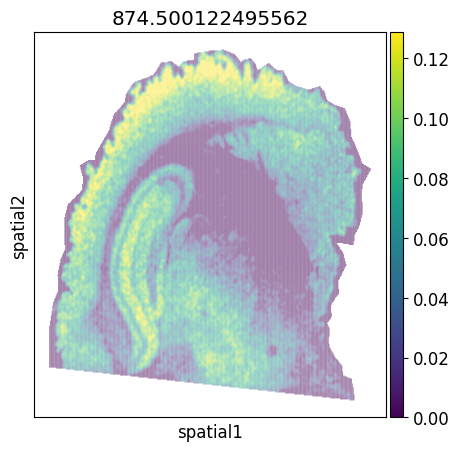

In [56]:
plot_gene = '874.500122495562'
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '837.670012242575'}, xlabel='spatial1', ylabel='spatial2'>

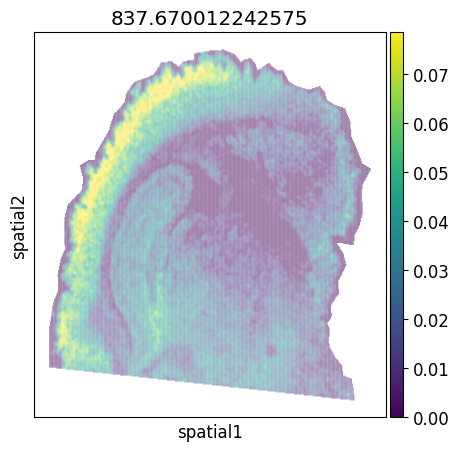

In [55]:
plot_gene = '837.670012242575'
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

<Axes: title={'center': '716.454992639195'}, xlabel='spatial1', ylabel='spatial2'>

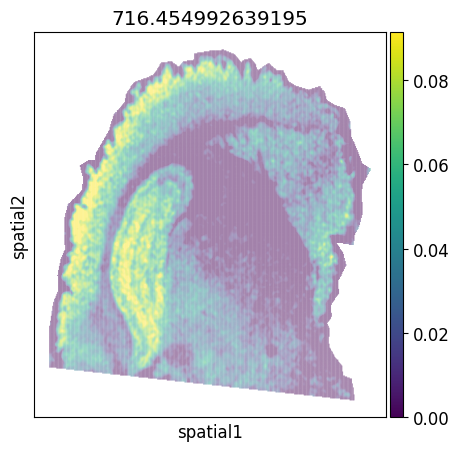

In [54]:
plot_gene = '716.454992639195'
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(new_adata, basis="spatial", layer = 'STMGraph_ReX',color=plot_gene, show=False,vmax='p99',ax=ax)

## **4 SRMGraph Cluster**

In [47]:
adata_REX = anndata_transfer_resolution2(adata=adata0123,pixel_size=30)
# adata_REX = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15um_c_new.h5ad')
adata_REX.X=new_adata.layers['STMGraph_ReX']

In [57]:
adata_REX.obs_names = new_adata.obs_names

In [37]:
# Cluser

In [58]:
adata_REX_h = adata_REX.copy()  # 创建一个副本
# sc.pp.highly_variable_genes(adata_REX_h, flavor="seurat_v3", n_top_genes=300)
# sc.pp.normalize_total(adata_REX_h, target_sum=1e4)
# sc.pp.log1p(adata_REX_h)
# adata_REX_h = adata_REX_h[:, adata_REX_h.var['highly_variable']]

In [59]:
# grid setting
num_batch_x = 3
num_batch_y = 2
adata_REX_h = adata_REX_h.copy()  # 将视图转换为副本
adata_REX_h.obs['x'] = adata_REX_h.obsm['spatial'][:,0]
adata_REX_h.obs['y'] = adata_REX_h.obsm['spatial'][:,1]

In [60]:
import seaborn as sns
def Batch_Data(adata, num_batch_x, num_batch_y, spatial_key=['X', 'Y'], plot_Stats=False):
    Sp_df = adata.obs.loc[:, spatial_key].copy()
    Sp_df = np.array(Sp_df)
    batch_x_coor_1 = [np.percentile(Sp_df[:, 0], (1/num_batch_x)*x*100) for x in range(num_batch_x+1)]
    batch_y_coor_1 = [np.percentile(Sp_df[:, 1], (1/num_batch_y)*x*100) for x in range(num_batch_y+1)]
    batch_x_coor_2 = [np.percentile(Sp_df[:, 0], (1/(num_batch_x*2))*x*100) for x in range(1,num_batch_x*2+1,2)]
    batch_y_coor_2 = [np.percentile(Sp_df[:, 1], (1/(num_batch_y*2))*x*100) for x in range(1,num_batch_y*2+1,2)]
    
    Batch_list = []
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y-1):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x-1):
        for it_y in range(num_batch_y):
            min_x_2 = batch_x_coor_2[it_x]
            max_x_2 = batch_x_coor_2[it_x+1]
            min_y_1 = batch_y_coor_1[it_y]
            max_y_1 = batch_y_coor_1[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_2 <= x <= max_x_2)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_1 <= y <= max_y_1)]
            Batch_list.append(temp_adata)
    
    for it_x in range(num_batch_x):
        for it_y in range(num_batch_y-1):
            min_x_1 = batch_x_coor_1[it_x]
            max_x_1 = batch_x_coor_1[it_x+1]
            min_y_2 = batch_y_coor_2[it_y]
            max_y_2 = batch_y_coor_2[it_y+1]
            temp_adata = adata.copy()
            temp_adata = temp_adata[temp_adata.obs[spatial_key[0]].map(lambda x: min_x_1 <= x <= max_x_1)]
            temp_adata = temp_adata[temp_adata.obs[spatial_key[1]].map(lambda y: min_y_2 <= y <= max_y_2)]
            Batch_list.append(temp_adata)
    if plot_Stats:
        f, ax = plt.subplots(figsize=(1, 3))
        plot_df = pd.DataFrame([x.shape[0] for x in Batch_list], columns=['#spot/batch'])
        sns.boxplot(y='#spot/batch', data=plot_df, ax=ax)
        sns.stripplot(y='#spot/batch', data=plot_df, ax=ax, color='red', size=5)
    return Batch_list

In [ ]:
Batch_list_2 = Batch_Data(adata_REX_h, num_batch_x=num_batch_x, num_batch_y=num_batch_y,spatial_key=['x', 'y'], plot_Stats=True)

In [ ]:
# Consturcting network for each batch
for temp_adata in Batch_list_2:
    STMGraph_pyG1.Cal_Spatial_Net(temp_adata, model='KNN', k_cutoff=8, delta_err=0.05)
    #STAGATE_pyG.Stats_Spatial_Net(temp_adata)

In [ ]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
data_list2 = [STMGraph_pyG1.Transfer_pytorch_Data(temp_adata) for temp_adata in Batch_list_2]
for temp in data_list2:
    temp.to(device)

In [ ]:
STMGraph_pyG1.Cal_Spatial_Net(adata_REX_h, model='KNN', k_cutoff=8, delta_err=0.05)
adata_om2 = STMGraph_pyG1.Transfer_pytorch_Data(adata_REX_h)

In [ ]:
from torch_geometric.loader import DataLoader

# hyper-parameters
# num_epoch = 500
# delayed_ema_epoch = 110
# lr=0.0001
# weight_decay=1e-4
# hidden_dims = [512, 30]
# alpha = 1
# mask_ratio = 0.5
# noise = 0.0
# gradient_clipping = 5.0

import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

def sce_loss(x, y, alpha=1.0):
    x = F.normalize(x, p=2, dim=-1)
    y = F.normalize(y, p=2, dim=-1)
    loss = (1 - (x * y).sum(dim=-1)).pow_(alpha)

    loss = loss.mean()
    return loss
seed=52
fix_seed(seed)
# batch_size=1 or 2
loader = DataLoader(data_list2, batch_size=1, shuffle=True,num_workers = 0)
model = STMGraph_pyG1.STMGraph(hidden_dims = [data_list2[0].x.shape[1]]+hidden_dims, delayed_ema_epoch=delayed_ema_epoch, momentum=0.99).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

total_steps = num_epoch * len(loader)
pbar = tqdm(total=total_steps, desc='Training')

for epoch in range(1, num_epoch + 1):
    for batch in loader:
        model.train()
        optimizer.zero_grad()

        z, z_ema, out1, out2, mask_nodes, keep_nodes, ATT = model(
            epoch, batch.x, batch.edge_index,
            mask_rate=mask_ratio, replace_rate=noise
        )

        loss1 = sce_loss(batch.x[mask_nodes], out1[mask_nodes], alpha=alpha) \
              + sce_loss(batch.x[mask_nodes], out2[mask_nodes], alpha=alpha)
        loss2 = F.mse_loss(z[keep_nodes], z_ema[keep_nodes])
        loss = loss1 + loss2

        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)#  gradient_clipping
        optimizer.step()

        # 只保留 epoch 和 loss
        pbar.set_postfix({'epoch': epoch, 'loss': f'{loss.item():.4f}'})
        pbar.update(1)
pbar.close()

In [ ]:
# The total network
device_cpu = torch.device('cpu')
adata_om2.to(device_cpu)
model.to(device_cpu)

In [ ]:
model.eval()
z, z_ema, out_1, out_2, mask_nodes, keep_nodes,ATT = model(epoch,adata_om2.x, adata_om2.edge_index, mask_rate=0, replace_rate=0)
STMGraph_rep = z.to('cpu').detach().numpy()
adata_REX_h.obsm['STMGraph'] = STMGraph_rep

In [ ]:
adata_REX_h = STMGraph_pyG1.mclust_R(adata_REX_h, used_obsm='STMGraph', num_cluster=15)

In [ ]:
adata.obsm['STMGraph'].shape

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'STMGraph'}, xlabel='spatial1', ylabel='spatial2'>

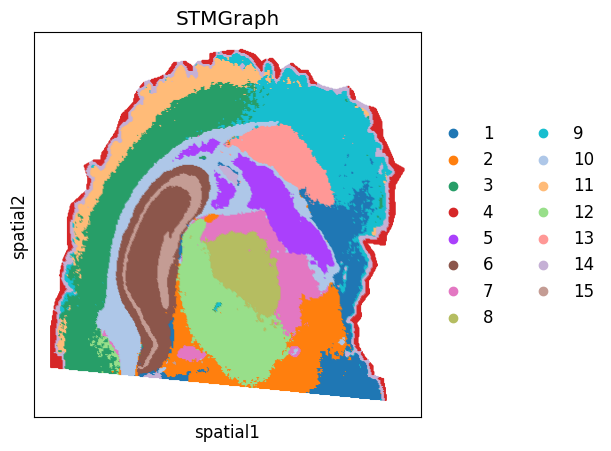

In [61]:
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
sc.pl.embedding(adata_REX_h, basis="spatial", color="mclust",s=10, show=False, title='STMGraph', ax=ax)

In [66]:
adata_REX_h.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15-30-15um_c_new.h5ad')

In [2]:

adata30 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_ito_30um_mad.h5ad')

In [3]:

adata_3015 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_ito_30um_mad_rex_h.h5ad')# 30->15

In [4]:
adata15 = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15um_c_new.h5ad')

In [5]:
adata_REX_h = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15-30-15um_c_new.h5ad')

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


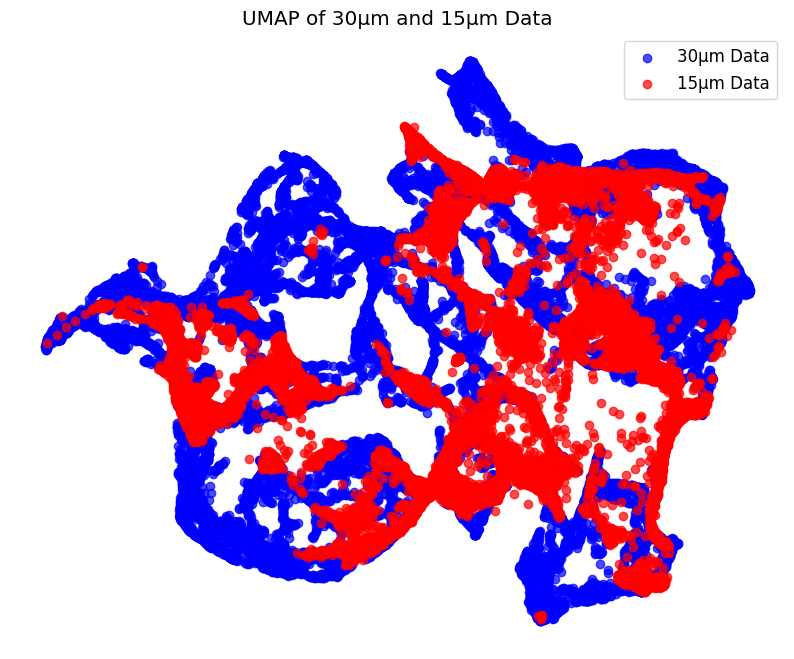

In [36]:
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA

# 1. 数据准备与PCA降维
# 从AnnData对象中获取数据 (假设 adata30 和 new_adata 已定义)
adata_30 = adata30.obsm['STMGraph']
adata_15 = adata15.obsm['STMGraph']

# 初始化PCA模型
pca = PCA(n_components=10, random_state=42)

# 注意：通常建议用同一组数据fit，或者分别fit。
# 这里保持你原有的逻辑，分别进行fit_transform
adata30_pca = pca.fit_transform(adata_30)
adata15_pca = pca.fit_transform(adata_15)

# 检查维度一致性
assert adata30_pca.shape[1] == adata15_pca.shape[1], "维度必须一致"

# 2. UMAP 建模与转换
# 初始化UMAP模型
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)

# 对30µm数据进行拟合并转换
embedding_rna = umap_model.fit_transform(adata30_pca)

# 对15µm数据进行转换 (基于已训练的模型)
embedding_protein = umap_model.transform(adata15_pca)

# 3. 绘图
plt.figure(figsize=(10, 8))

# 绘制 30µm 数据
plt.scatter(embedding_rna[:, 0], embedding_rna[:, 1], c='blue', label='30µm Data', alpha=0.7)

# 绘制 15µm 数据
plt.scatter(embedding_protein[:, 0], embedding_protein[:, 1], c='red', label='15µm Data', alpha=0.7)

# 添加图例和标签
plt.title('UMAP of 30µm and 15µm Data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()

# --- 关键修改：隐藏坐标轴 ---
plt.axis('off') 

# 显示图表
plt.show()

In [27]:
adata_REX_h=sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_STMGrpah_pyG1_bruker_ITO_glass_15-30-15um_c_new.h5ad')
import SM2ST_wmse as SM2ST
r_values,p_values = SM2ST.calculate_median_pearsonr(adata,adata_REX_h)

Median r across all rows: 0.9147777653160836
Mean r across all rows: 0.9117378810441154


/tmp/ipykernel_391283/3739926958.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(r_values,


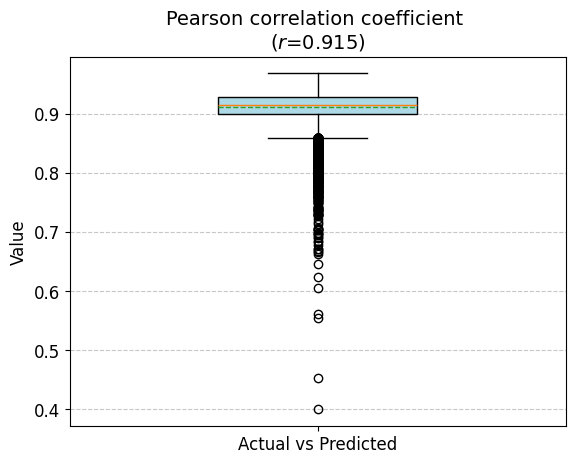

In [24]:
box = plt.boxplot(r_values, 
                  patch_artist=True, 
                  labels=['Actual vs Predicted'], # x轴标签
                  widths=0.4,          # 箱体宽度
                  showmeans=True,      # 显示平均值（绿色三角形）
                  meanline=True)       # 平均值用线表示

# 4. 美化箱体颜色 (可选)
plt.gca().patches[0].set_facecolor('#ADD8E6') # 设置箱体颜色为浅蓝色
plt.gca().patches[0].set_edgecolor('black')   # 设置边框颜色

# 5. 添加标题和标签
plt.title('Pearson correlation coefficient \n($r$=0.915)', fontsize=14)
plt.ylabel('Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # 添加Y轴网格

# 6. 显示图形
plt.show()

In [11]:
import pandas as pd
import numpy as np
from scipy import stats

def icc_anova(x, group):
    """
    单因素 ANOVA 法计算 ICC(1,1)  （无条件、单测评者）
    x : 1-D 表达向量
    group : 簇标签，与 x 同长度
    """
    group = pd.Categorical(group)
    k = len(group.categories)          # 簇数
    n_i = group.value_counts().values  # 各簇样本数
    n0 = n_i.mean()                    # 平均簇大小

    # 快速 ANOVA
    grand_mean = x.mean()
    ss_total = ((x - grand_mean)**2).sum()

    ss_between = 0
    for g, idx in enumerate(group.categories):
        mask = group == idx
        ss_between += mask.sum() * (x[mask].mean() - grand_mean)**2
    ss_within = ss_total - ss_between

    df_between = k - 1
    df_within = x.size - k
    ms_between = ss_between / df_between
    ms_within  = ss_within  / df_within

    if ms_between <= ms_within:        # 边界保护
        return 0.0
    icc = (ms_between - ms_within) / (ms_between + (n0 - 1)*ms_within)
    return max(0.0, icc)

def cluster_icc(adata, cluster_key='louvain'):
    """为 adata 的每条基因计算 cluster-level ICC"""
    icc_list = []
    genes = adata.var_names
    clusters = adata.obs[cluster_key]
    for g in genes:
        icc_list.append(icc_anova(adata[:, g].X.toarray().ravel()
                                  if hasattr(adata.X, 'toarray')
                                  else adata[:, g].X.ravel(),
                                  clusters))
    adata.var['icc'] = icc_list
    return adata

In [12]:
cluster_icc(adata30, cluster_key='mclust')

# 查看高 ICC 基因
high_icc30 = adata30.var.sort_values('icc', ascending=False)
print(high_icc30[['icc']])

                       icc
772.525756678705  0.779965
773.530434153953  0.776580
844.525853875026  0.770875
774.529178531594  0.768115
854.600996747458  0.768002
...                    ...
760.443312556395  0.000000
560.939129867335  0.000000
759.43514202819   0.000000
563.406812922209  0.000000
1024.56013307813  0.000000

[1389 rows x 1 columns]


In [13]:
cluster_icc(adata15, cluster_key='mclust')

# 查看高 ICC 基因
high_icc15 = adata15.var.sort_values('icc', ascending=False)
print(high_icc15[['icc']])

                       icc
772.52428787237   0.801538
773.529221269257  0.791406
769.563470969662  0.784949
756.553628666711  0.776190
826.571693964066  0.762307
...                    ...
670.309641707379  0.000243
620.428426338082  0.000220
812.511783736698  0.000205
314.276985063161  0.000199
696.464939511634  0.000099

[954 rows x 1 columns]


In [15]:
cluster_icc(adata_3015, cluster_key='mclust')

# 查看高 ICC 基因
high_icc3015 = adata_3015.var.sort_values('icc', ascending=False)
print(high_icc3015[['icc']])

                       icc
752.526090973169  0.893102
606.235025566069  0.891341
855.603012904827  0.890730
253.964758880211  0.888560
556.220600053111  0.888484
...                    ...
818.557522463802  0.000000
344.999604983346  0.000000
255.893322841007  0.000000
658.350955891733  0.000000
508.28185995209   0.000000

[1389 rows x 1 columns]


In [16]:
cluster_icc(adata_REX_h, cluster_key='mclust')

# 查看高 ICC 基因
high_icc_REX_h = adata_REX_h.var.sort_values('icc', ascending=False)
print(high_icc_REX_h[['icc']])

                       icc
426.358142652172  0.912105
372.310878825464  0.908711
400.342422117033  0.908292
814.630588200756  0.901913
217.048974169876  0.901231
...                    ...
685.417397051537  0.083422
766.540976474486  0.075900
805.49349650122   0.067486
798.596365201721  0.065570
505.229652507523  0.019184

[954 rows x 1 columns]


In [23]:
# 1. 去掉 ICC 为 0（或 NaN）的基因
keep15 = adata15.var['icc'] > 0
adata_filt_15 = adata15[:, keep15].copy()
print(f"保留基因数：{adata_filt_15.n_vars}")
icc_df_15 = adata_filt_15.var[['icc']].reset_index(drop=True)

保留基因数：954


In [24]:
# 1. 去掉 ICC 为 0（或 NaN）的基因
keep_rex_h = adata_REX_h.var['icc'] > 0
adata_filt_rex_h = adata_REX_h[:, keep_rex_h].copy()
print(f"保留基因数：{adata_filt_rex_h.n_vars}")
icc_df_rex_h = adata_filt_rex_h.var[['icc']].reset_index(drop=True)

保留基因数：954


In [25]:
# 1. 去掉 ICC 为 0（或 NaN）的基因
keep_30 = adata30.var['icc'] > 0
adata_filt_30 = adata30[:, keep_30].copy()
print(f"保留基因数：{adata_filt_30.n_vars}")
icc_df_30 = adata_filt_30.var[['icc']].reset_index(drop=True)

保留基因数：1024


In [27]:
# 1. 去掉 ICC 为 0（或 NaN）的基因
keep_3015 = adata_3015.var['icc'] > 0
adata_filt_3015 = adata_3015[:, keep_3015].copy()
print(f"保留基因数：{adata_filt_3015.n_vars}")
icc_df_3015 = adata_filt_3015.var[['icc']].reset_index(drop=True)

保留基因数：1381


In [28]:
icc_df_3015

,icc
0,0.397305
1,0.590701
2,0.326826
3,0.783177
4,0.275044
...,...
1376,0.090380
1377,0.593698
1378,0.015624
1379,0.564918


/tmp/ipykernel_460947/2521875170.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Resolution', y='ICC', palette=['skyblue', 'lightcoral','moccasin','lightgreen'])


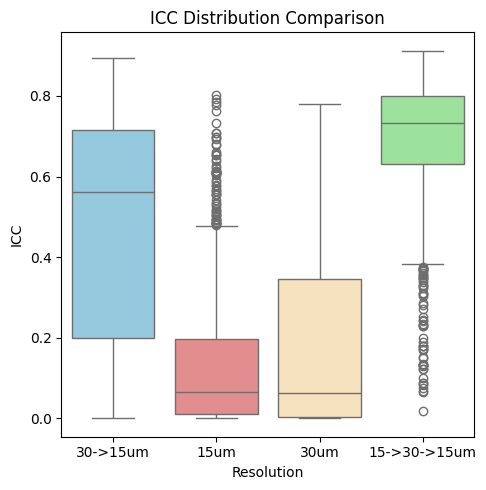

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 构造数据（假设你已经有了 icc_df_rex_h 和 icc_df）
icc_df_3015['Resolution'] = '30->15um'
icc_df_15['Resolution'] = '15um'
icc_df_30['Resolution'] = '30um'
icc_df_rex_h['Resolution'] = '15->30->15um'


# 合并数据
combined_df = pd.concat([
    icc_df_3015.rename(columns={'icc': 'ICC'}),
    icc_df_15.rename(columns={'icc': 'ICC'}),
    icc_df_30.rename(columns={'icc': 'ICC'}),
    icc_df_rex_h.rename(columns={'icc': 'ICC'})
], ignore_index=True)

# 绘图
plt.figure(figsize=(5, 5))
sns.boxplot(data=combined_df, x='Resolution', y='ICC', palette=['skyblue', 'lightcoral','moccasin','lightgreen'])
plt.title('ICC Distribution Comparison')
plt.ylabel('ICC')
plt.xlabel('Resolution')
plt.tight_layout()
plt.show()